In [1]:
import logging
from trails import Trails, lca, get_lcia_method_names, plot_temporal_scores
from datapackage import Package
from trails.logging import configure_trails_logging, trails_log_context

configure_trails_logging(file_level=logging.DEBUG)

dp = Package("datapackage.json")
#dp = Package("/Users/romain/GitHub/premise/dev/trails_2025-12-16.zip")
trails = Trails(dp, interpolate_annual=True)

#methods = ["IPCC 2021 - climate change: fossil - global warming potential (GWP100)",]
methods = ["IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",]

/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading matrices from data package          [1/3]
Loading indices from data package           [2/3]
Interpolating matrices to annual resolution [3/3]


In [2]:
ref_year = 2050

results_by_year_ICEV, provenance = lca(
    trails,
    start_year=ref_year,
    start_act_idx=13,
    #start_act_idx=27826,
    methods=methods,
    max_depth=4,
    return_provenance=True,
    show_progress=True,
    min_amount=1e-18,
    debug=True
)

Temporal LCA: impact years: 100%|██████████| 55/55 [00:00<00:00, 68069.26year/s]


In [3]:
ref_year = 2050
results_static_ICEV = lca(
    trails,
    start_year=ref_year,
    start_act_idx=13,
    #start_act_idx=27826,
    methods=methods,
    max_depth=4,
    return_provenance=False,
    show_progress=True,
    min_amount=1e-18,
    use_temporal_distributions=False
)

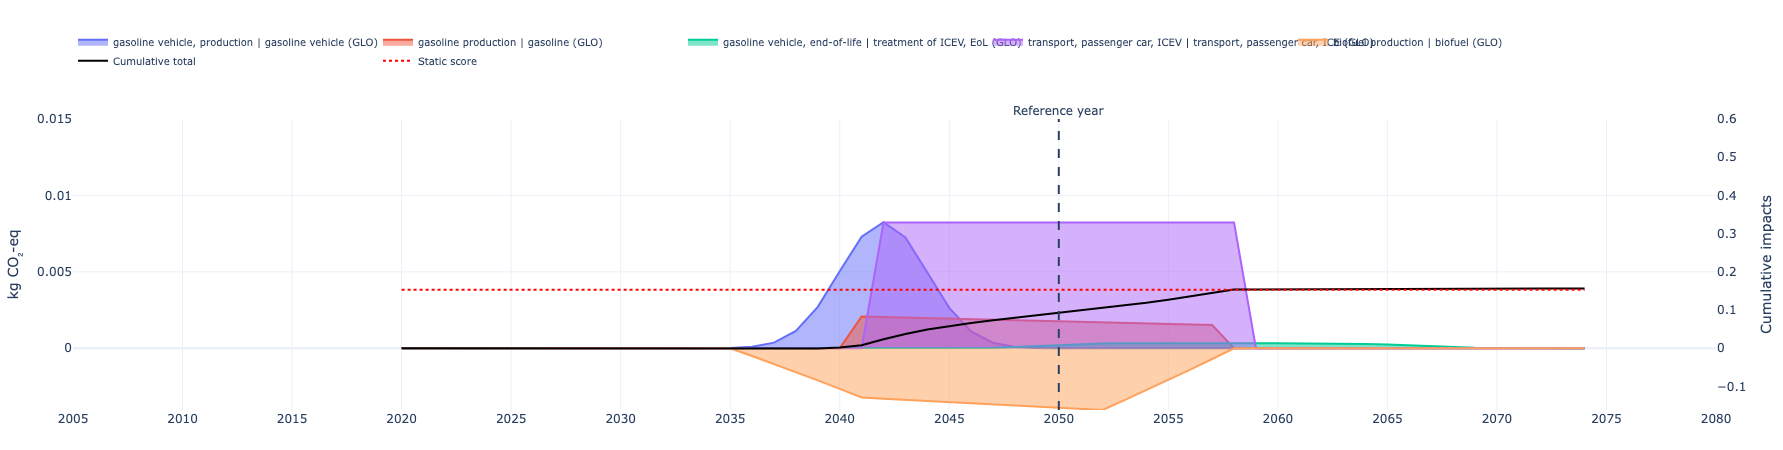

In [5]:
fig = plot_temporal_scores(
    results_by_year=results_by_year_ICEV["results_by_impact_year"],
    stacked=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=results_static_ICEV["results_by_solve_year"][ref_year]["scores"],
    static_score_dash= "dot",
    static_score_color= "red",
    y_max=0.015,
    y2_max=0.60
)
fig.show()

In [6]:
ref_year = 2050
results_by_year_BEV, provenance = lca(
    trails,
    start_year=ref_year,
    start_act_idx=2,
    methods=methods,
    max_depth=4,
    return_provenance=True,
    show_progress=True,
    min_amount=1e-18
)

Temporal LCA: impact years: 100%|██████████| 61/61 [00:00<00:00, 87650.75year/s]


In [7]:
results_static_BEV = lca(
    trails,
    start_year=ref_year,
    start_act_idx=2,
    methods=methods,
    max_depth=4,
    return_provenance=False,
    show_progress=False,
    min_amount=1e-18,
    use_temporal_distributions=False
)

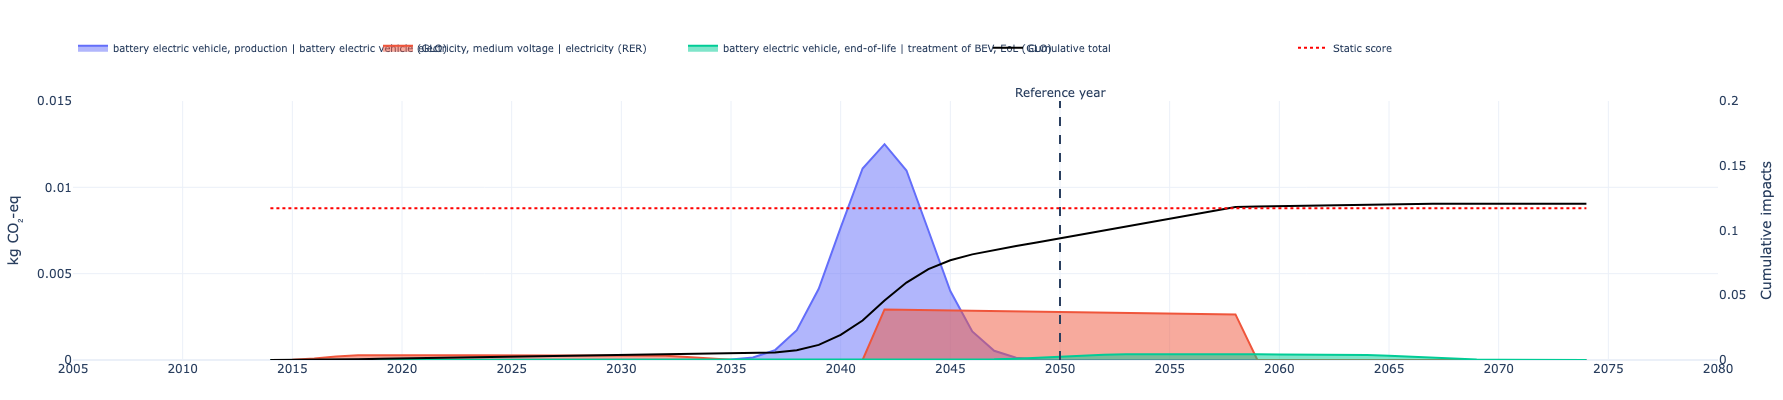

In [8]:
fig = plot_temporal_scores(
    results_by_year=results_by_year_BEV,
    stacked=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=400,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=results_static_BEV["results_by_solve_year"][ref_year]["scores"],
    static_score_dash= "dot",
    static_score_color= "red",
    y_max=0.015,
    y2_max=0.20
)
fig.show()

In [5]:
results_by_year_BEV

{'results_by_solve_year': {2014: {'fu_activity': 2,
   'FU_DIRECT_ROOT': 2,
   'fu_demand': {4: 6.256727565311791e-18},
   'demand_by_first_level_child': {1: {4: 6.256727565311791e-18}},
   'injected_supply': {},
   'injected_supply_by_first_level_child': {},
   'lca': <bw2calc.lca.LCA at 0x1427ada90>,
   'scores': 0.0,
   'scores_by_first_level_child': {1: 0.0}},
  2015: {'fu_activity': 2,
   'FU_DIRECT_ROOT': 2,
   'fu_demand': {4: 8.247927075607096e-17},
   'demand_by_first_level_child': {1: {4: 8.247927075607096e-17}},
   'injected_supply': {},
   'injected_supply_by_first_level_child': {},
   'lca': <bw2calc.lca.LCA at 0x142491950>,
   'scores': 0.0,
   'scores_by_first_level_child': {1: 0.0}},
  2016: {'fu_activity': 2,
   'FU_DIRECT_ROOT': 2,
   'fu_demand': {4: 4.24085018023215e-16},
   'demand_by_first_level_child': {1: {4: 4.24085018023215e-16}},
   'injected_supply': {},
   'injected_supply_by_first_level_child': {},
   'lca': <bw2calc.lca.LCA at 0x1425a1990>,
   'scores': 0

In [6]:
t = trails.scenario_index[str(trails._map_year_to_scenario_year(2045))]

print("A row nnz for act 0:", trails.A[t, 0, :].nnz)
print("B row nnz for act 0:", trails.B[t, 0, :].nnz)

print("B row for act 0 (dense):", trails.B[t, 0, :].todense())


A row nnz for act 0: 1
B row nnz for act 0: 1
B row for act 0 (dense): [12333.334     0.   ]


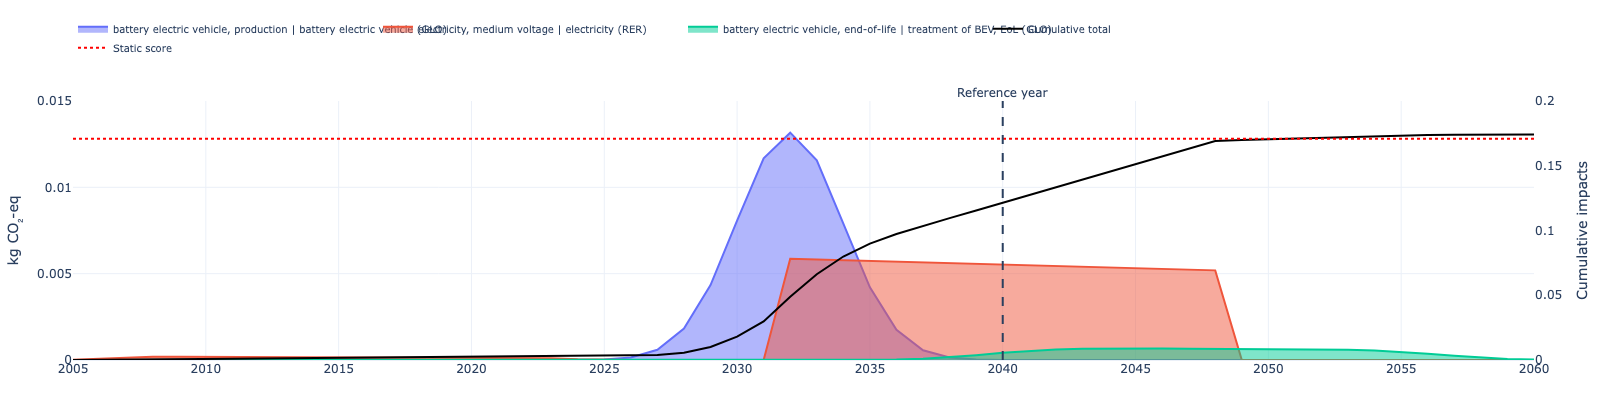

In [12]:
fig = plot_temporal_scores(
    results_by_year=results_by_year_BEV,
    stacked=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=400,
    year_tick=5,
    year_range=(2005, 2060),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=results_static_BEV[2040]["scores"],
    static_score_dash= "dot",
    static_score_color= "red",
    y_max=0.015,
    y2_max=0.20
)
fig.show()

In [6]:
from trails.plotting import plot_traversal_grid_flow
edges_by_depth = trails.collect_traversal_edges(
    start_year=2050,
    start_act_idx=13,
    amount=1.0,
    max_depth=5,
    min_amount=1e-18,
)

fig = plot_traversal_grid_flow(
    edges_by_depth=edges_by_depth,
    trails=trails,
    depths=None,                 
    include_all_activities=True,
    title="Traversal flows by depth",
    dot_size=5,
)

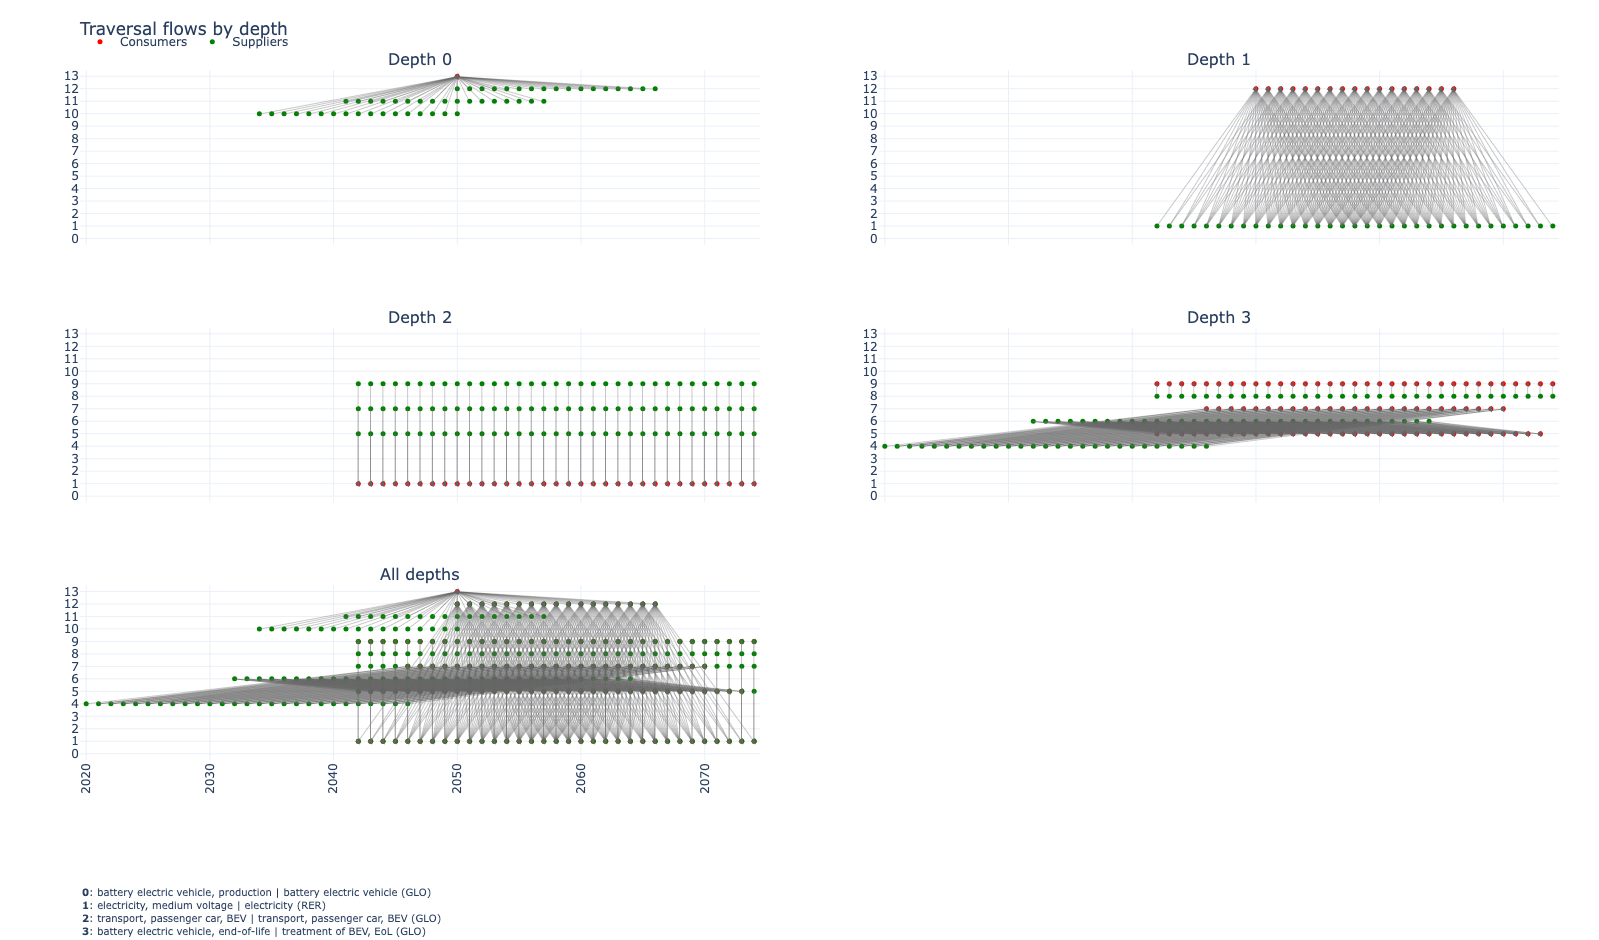

In [7]:
fig

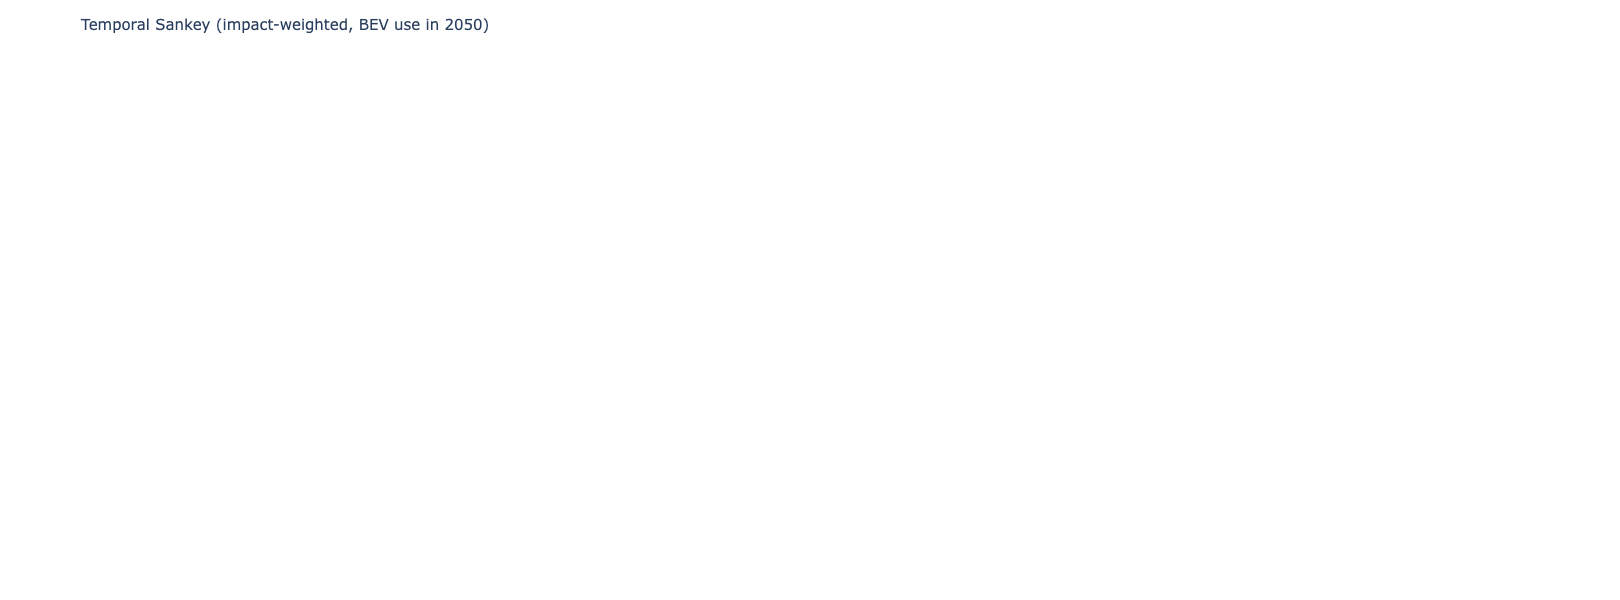

In [8]:
from trails.plotting import plot_temporal_sankey
fig = plot_temporal_sankey(
    provenance=provenance,
    trails=trails,
    start_year=2050,
    start_act_idx=2,
    methods=methods,
    top_n_paths=None,                # or None to show all
    title="Temporal Sankey (impact-weighted, BEV use in 2050)",
    amount_label="Impact (kg CO2-eq)",  # or whatever the method unit is
    fig_width=1600,
    fig_height=600,
)

fig.show()

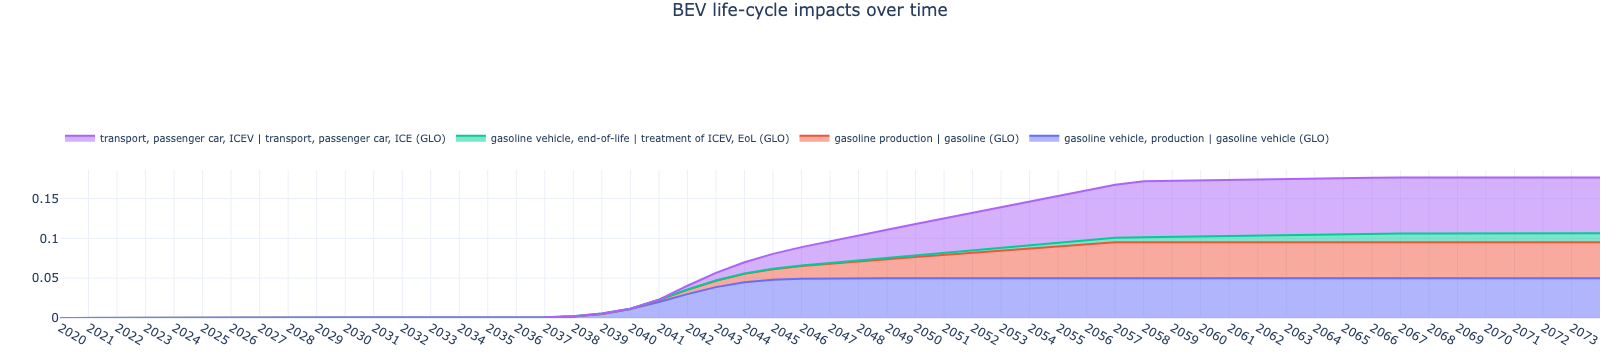

In [9]:
fig = plot_temporal_scores(
    results_by_year=results_by_year,
    trails=trails,
    title="BEV life-cycle impacts over time",
    method_label="kg CO₂-eq",
    cumulative=True
)
fig.show()

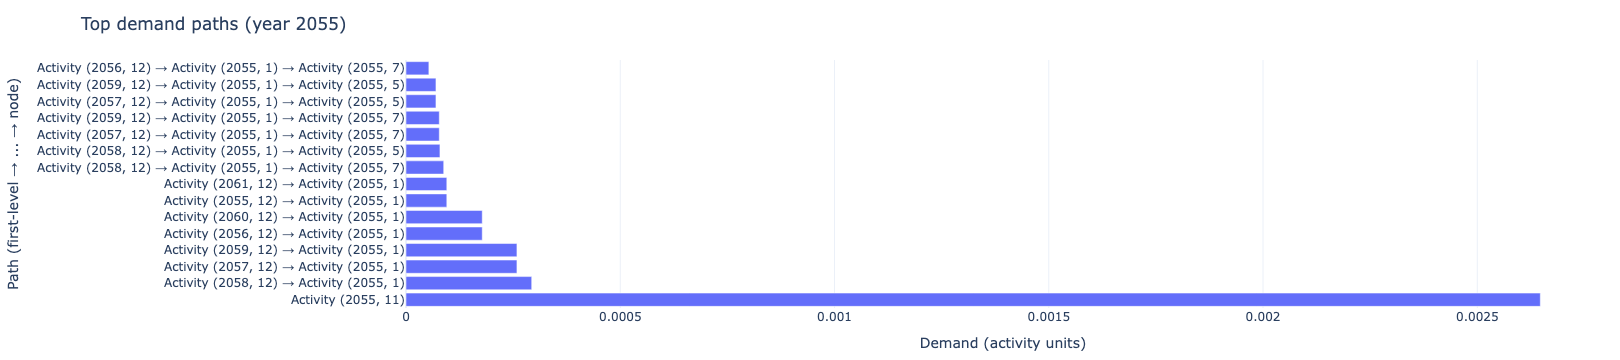

In [10]:
from trails.plotting import plot_top_paths_for_year
plot_top_paths_for_year(
    provenance=provenance,
    trails=trails,
    year=2055,
    top_n=15,
    title="Top demand paths",
    amount_label="Demand (activity units)",
)

In [11]:
fig_d2

NameError: name 'fig_d2' is not defined

In [ ]:
from trails.lca import build_datapackage_for_year_from_trails
from trails.lcia import get_lcia_methods

year = 2049  # or any year that appears in results

dp, tech_idx, bio_idx, uncertain_params = build_datapackage_for_year_from_trails(
    trails=trails,
    year=year,
    remove_uncertainty=True,
)

lca = results[year]["lca"]
biosphere_matrix_dict = lca.dicts.biosphere  # {flow_id: row index}

# Build the mapping expected by fill_characterization_factors_matrices
biosphere_dict_simple = {
    (name, comp, subcomp): idx
    for (name, comp, subcomp, unit), idx in bio_idx.items()
}

print("Sample biosphere flows from DB:")
for k in list(biosphere_dict_simple.keys())[:10]:
    print("  DB  :", k)

# Use the same 'methods' list you passed to temporal_lcia_from_trails
lcia_data = get_lcia_methods(methods=methods)

print("\nSample LCIA flows from first method:")
m0 = methods[0]
for k in list(lcia_data[m0].keys())[:10]:
    print("  LCIA:", k)

intersection = set(lcia_data[m0].keys()) & set(biosphere_dict_simple.keys())
print("\nNumber of matching flows:", len(intersection))
print("Some matches:", list(intersection)[:10])


In [ ]:
print("Sample bio_idx entries:")
for k, v in list(bio_idx.items())[:10]:
    print("  key:", k, "value:", v)


In [ ]:
result = trails.expand_temporal_exchanges(year=2050, act_idx=1, amount=1.0)
result

In [ ]:
frontier = trails.temporal_traversal(
    start_year=2050,
    start_act_idx=1,
    amount=1.0,
    max_depth=2,      # say 2 layers for now
    min_amount=1e-12,
)

len(frontier), list(frontier.items())[:10]


In [ ]:
dp = Package("datapackage.json")

In [ ]:
from trails import Trails

In [ ]:
trails = Trails(dp)

In [ ]:
a3.temporal_distributions

In [ ]:
a3.A.dtype

In [ ]:
a3.B.dtype

In [ ]:
a3.scenario_index

In [ ]:
a3.scenario_labels

In [ ]:
a3.activity_indices

In [ ]:
a3.biosphere_index